Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно
***

# Часть 1 (6+ pt)

В этом домашнем задании вы познакомитесь с **разведовательным анализом** (EDA). На самом деле, разведывательный анализ — это не что-то съверхестественное. Более того, в предыдущих заданиях вы уже в какой-то мере его совершали.

**EDA (Exploratory Data Analysis)** — это первый и критически важный этап работы с данными, на котором вы «знакомитесь» с набором данных через визуализации и статистические резюме. Через EDA:
> - Обнаруживаете аномалии и пропуски
> - Понимаете распределение признаков
> - Выявляете взаимосвязи между переменными
> - Формулируете гипотезы для дальнейшей проверки

Звучит знакомо, правда?

Поэтому в этой домашке мы скорее соберем все навыки воедино и дополним их **статистикой** и **визуализацией**!

Будем руководствоваться следующими вопросами:
* Как распределены значения признаков?
* Какие признаки связаны между собой?
* Какие закономерности скрыты в данных?
* Какие гипотезы можно сформулировать для дальнейшего анализа?

В ноутбуке как всегда будут теоретические справки, но полезно еще почитать [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html?spm=a2ty_o01.29997173.0.0.33be5171FMA4h7),
[Understanding Correlation](https://seaborn.pydata.org/examples/many_pairwise_correlations.html?spm=a2ty_o01.29997173.0.0.33be5171FMA4h7),
[Pandas Statistical Functions](https://pandas.pydata.org/docs/reference/general_functions.html?spm=a2ty_o01.29997173.0.0.33be5171FMA4h7#computational-descriptive-stats).

***
В этой части будем использовать датасет `diamonds` из `seaborn` (значения столбцов можно посмотреть в интернетах). Мы уже умеем загружать такие датасеты, сделаем это.

In [ ]:
# Возможно вам нужно установить библиотеки
%pip install ...

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Pandas version: {pd.__version__}")
print(f"Seaborn version: {sns.__version__}")

Pandas version: 2.3.3
Seaborn version: 0.13.2


In [2]:
diamonds = sns.load_dataset('diamonds')
diamonds.shape

(53940, 10)

### Знакомство с данными (1 pt)

**ЗАДАНИЕ: базово исследуйте и очистите данные, напишите небольшой вывод.**

Можете ориентироваться на следующие важные пункты:
* Столбцы, их значение и типы их значений
* Количество уникальных значений
* Границы значений
* Пропуски
* Дубликаты

In [ ]:
diamonds.head()

In [ ]:
...

In [ ]:
# Поменяйте тип ячейки на Markdown и напишите вывод:
**ВЫВОД:**

### Одномерный анализ (3 pt)

После того, как вы «окинули взглядом» данные и применили те методы, которые уже знаете, перейдем к статистическому анализу и более глубокому пониманию.

В этом пункте мы поговорим про **одномерный анализ**, то есть про анализ каждого признака по отдельности _(можно найти и другие определения, не претендую на единсвенно верное)_.

Важными для одномерного анализа являются **мера центральности** и **мера разброса**, а также сама форма распределений. Давайте поговорим про них по отдельности.

***
Центрирование данных можно описать через три ключевые меры:
| Мера | Функция | Когда использовать |
| ---- | ------- | ------------------ |
| **Среднее** | `.mean()` | Для симметричных распределений без выбросов |
| **Медиана** | `.median()` | Для асимметричных распределений или при наличии выбросов |
| **Мода** (наиболее частое значение) | `.mode()` | Для категориальных данных или мультимодальных распределений |

Все три меры, безусловно, дают нам информацию о распределении данных и мы можем делать из этого выводы (например если среднее сильно отличается от медианы). Однако пукнт _«Когда использовать»_ говорит о том, когда эту меру стоит использовать для информативного описания распределения в дальнейшем (или для использования статистики при каких-то вычислениях).

In [ ]:
# ЗАДАНИЕ:
#          1. Рассчитайте подходящие статистики для каждого из столбцов.
#          2. Объясните расхождения между средним и медианой, если такие есть.
#          3. Напишите вывод (ваши гипотезы) о распределении данных на основе мер центральности.

...

_Почему для цены среднее > медианы? Что это говорит о распределении цен?_

In [ ]:
# Поменяйте тип ячейки на Markdown и напишите вывод:
**ВЫВОД:** 

***
Одной меры центральности недостаточно для описания распределения. Еще одной важной мерой для описания данных является **мера разброса** _(мы уже немного затрагивали эту тему, когда говорили про выявление аномалий)_, а также понимание пормы распределения.

Для описания разброса и формы данных можно использовать следующие статистики:

| Статистика | Функция | Описание | Интерпретация |
| ---------- | ------- | -------- | ------------- |
| **Дисперсия** | `.var()` | Обычная дисперсия | Среднее квадратов отклонения от среднего |
| **Стандартное отклонение** | `.std()` | Корень из дисперсии | Типичное отклонение от среднего |
| **Межквартильный размах (IQR)** | `.quantile()` | $IQR=Q3−Q1$ | Размах "центральных" 50% данных |
| **Асимметрия (skewness)** | `.skew()` | $\frac{1}{n} \sum\limits_{i=1}^n \Big( \frac{x_i - \tilde{x}}{\sigma} \Big)^3$ | >0: правый хвост длиннее; <0: левый хвост длиннее |
| **Эксцесс (kurtosis)** | `.kurtosis()` | $\frac{1}{n} \sum\limits_{i=1}^n \Big( \frac{x_i - \tilde{x}}{\sigma} \Big)^4 - 3$ | >0: островершинное; <0: плосковершинное |

Как всегда документация: [.var()](https://pandas.pydata.org/docs/reference/api/pandas.Series.var.html),
[.std()](https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html),
[.quantile()](https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html),
[.skew()](https://pandas.pydata.org/docs/reference/api/pandas.Series.skew.html),
[.kurtosis()](https://pandas.pydata.org/docs/reference/api/pandas.Series.kurtosis.html),
[и про эксцесс](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%8D%D1%84%D1%84%D0%B8%D1%86%D0%B8%D0%B5%D0%BD%D1%82_%D1%8D%D0%BA%D1%81%D1%86%D0%B5%D1%81%D1%81%D0%B0).

In [ ]:
# ЗАДАНИЕ:
#          1. Рассчитайте подходящие статистики для каждого из столбцов.
#          2. Напишите вывод о распределении данных, сходится ли это с выводами прошлого пункта?

...

_Как асимметрия > 1 влияет на выбор меры центральной тенденции?_

In [ ]:
# Поменяйте тип ячейки на Markdown и напишите вывод:
**ВЫВОД:** 

***
Теперь когда мы поняли, как статистики помогают понять распределения попробуем их **визуализировать** и сравнить выводы.

<div class="alert alert-info">
<i>В этом задании мы действуем в такой последовательности в учебных целях, однако визуализацию можно и нужно применять раньше! Скорее именно ее стоит использовать для выдвижения гипотез, а статистиками гипотезы подтверждать. В части 2 и дальнейших исследованиях стоит делать именно так</i> 
</div>

**Разные типы графиков показывают разные аспекты распределения:**

| Тип графика | Что показывает | Когда использовать |
| ----------- | -------------- | ------------------ |
| **Гистограмма** | Частота значений в интервалах | Общий обзор формы распределения |
| **KDE-plot** | Сглаженная оценка плотности | Сравнение нескольких распределений |
| **Boxplot** | Медиана, квартили, выбросы | Сравнение распределений по категориям |
| **Violinplot** | Комбинация boxplot + KDE | Детальное сравнение форм распределений |

Про применение и параметры в документации: [sns.histplot()](https://seaborn.pydata.org/generated/seaborn.histplot.html),
[sns.kdeplot()](https://seaborn.pydata.org/generated/seaborn.kdeplot.html),
[sns.boxplot()](https://seaborn.pydata.org/generated/seaborn.boxplot.html),
[sns.violinplot()](https://seaborn.pydata.org/generated/seaborn.violinplot.html).

В следующем домашнем задании мы подробнее остановимся на построении красывых графиков, поэтому не стоит заморачиваться в этом задании. Однако важно всегда придерживаться **баловых правил**:
* должно быть **понятно**, что изображено на графике;
* должны присутствовать **названия осей** (за исключением, когда это очевидно);
* если на графике присутствуют разные данные, то должна быть **легенда**.

In [ ]:
# ЗАДАНИЕ:
#          1. Постройте 4 типа визуализации для столбца 'price'.
#          2. Подтвердите (или опровергните) выводы предыдущих пунктов о распределениях других столбцов.
#          3. Напишите итоговый вывод о распределении данных.

...

plt.tight_layout()
plt.show()

_Какой график лучше всего показывает асимметрию распределения? Какой график лучше выявляет выбросы? Почему для цен бриллиантов медиана — более репрезентативная мера, чем среднее?_

In [ ]:
# Поменяйте тип ячейки на Markdown и напишите вывод:
**ВЫВОД:** 

### Двумерный анализ (2 pt)

После того, как вы подробно изучили распределение каждого из признаков, перейдем к изучению «влияния» признаков друг на друга. 

**Двумерный анализ** — анализ взаимосвязи призваков друг с другом.  
Самым простым подходом является анализ **распределения одного признака в зависимости от значения другого** (например распределение цены для разной огранки), однако вы уже должны быть способны это сделать (условная фильтрация в pandas + визуализация распределения), поэтому останавливаться на этом мы сейчас не будем. _Но обязательно примените этот анализ во второй части!_

***

В этом задании остановимся на анализе **корреляций** признаков. Важно помнить, что **корреляция $\neq$ причинно-следственная связь**! Корреляция измеряет силу и направление связи между двумя числовыми признаками.

**Будем рассматривать два типа корреляции** (подробнее про [корреляцию](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%80%D1%80%D0%B5%D0%BB%D1%8F%D1%86%D0%B8%D1%8F) в интренетах или на матстате):

| Тип корреляции | Что это такое | Когда использовать |
| -------------- | -------------- | ------------------ |
| **Пирсона** | 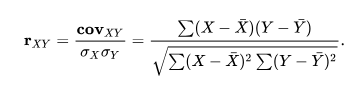 | Для линейных связей в нормально распределенных данных |
| **Спирмена** | Корреляция рангов | Для монотонных (не обязательно линейных) связей, устойчива к выбросам |

Документация: [.corr()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html),
[.spearmanr()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).

Корреляцию можно интерпретировать по-разному (разные градации/шкалы), но в целом логика такая: чем больше, тем сильнее величины связаны, если знак отрицательный, то «рост» одной связан с «падением» другой.

In [ ]:
# Нетрудно заметить, что корреляция работает только для числовых признаков,
# поэтому выберем только числовые столбцы из данных

numeric_diamonds = diamonds.select_dtypes(include=[np.number])

# ЗАДАНИЕ:
#          1. Рассчитайте матрицу корреляций Пирсона для числовых признаков
#          2. Найдите пару признаков с самой сильной положительной корреляцией
#          3. Рассчитайте корреляцию Спирмена для этой же пары признаков
#          4. Сравните значения Пирсона и Спирмена — отличаются ли они, почему?

...

In [ ]:
# Поменяйте тип ячейки на Markdown и напишите вывод:
**Ответ:** 

***
Оперировать числами довольно сложно, можно что-то пропустить. Как и написано в замечании в предыдущем разделе, проще «увидеть» гипотезы на картинке и уже числами их подтвердить. На помощь для двумерного анализа приходят новые типы графиков.

| Тип графика | Что показывает | Когда использовать | Ограничения | 
| ---------- | ------- | -------- | ------------- |
| **Heatmap** (тепловая карта) | Матрицу значений через цветовую кодировку | Быстрый обзор всех парных связей в числовых данных <br>Поиск сильных корреляций <br>Визуализация пропусков (`sns.heatmap(df.isna())`) |  Не показывает форму связи (линейная/нелинейная) <br>Трудно интерпретировать при >15 признаках |
| **Scatter plot** (точечная диаграмма) | Двумерное распределение точек | Анализ конкретной пары признаков <br>Проверка гипотезы о связи (напр., цена vs карат) <br>Визуализация категорий через цвет (`hue`) | Показывает только 2 признака за раз (+1 категориальный через `hue`) <br>Перекрытие точек при больших данных (`alpha` помогает) |
| **Pairplot** (матрица scatter plot) | Все попарные комбинации числовых признаков <br>Распределение на диагонали (гистограмма/KDE) | Быстрый обзор взаимосвязей в небольших датасетах (<10 признаков) <br>Поиск интересных пар для детального анализа | Квадратичная сложность: 10 признаков = 100 графиков! <br>Перегружен при большом количестве данных и долго считается |

Во всех этих графиках важна **настройка параметров** (иногда даже цветовая гпмма может влиять на интерпретируемость), поэтому внимательно посмотрите в документацию: [sns.heatmap()](https://seaborn.pydata.org/generated/seaborn.heatmap.html),
[sns.scatterplot()](https://seaborn.pydata.org/generated/seaborn.scatterplot.html),
[sns.pairplot()](https://seaborn.pydata.org/generated/seaborn.pairplot.html).

In [ ]:
# ЗАДАНИЕ:
#          1. Постройте тепловую карту (heatmap) матрицы корреляций Пирсона
#          2. Постройте scatter plot для пары признаков с максимальной корреляцией
#             - Добавьте линию регрессии (sns.regplot)
#          3. Постройте pairplot для признаков ['carat', 'price', 'depth'] с цветовым разделением по 'cut'

...

plt.tight_layout()
plt.show()

In [ ]:
# Поменяйте тип ячейки на Markdown и напишите вывод:
**ВЫВОД:** 

### Дополнительное задание (1+ pt)

Проанализируйте влияние категориального признака `cut` (качество огранки) на распределение цены бриллиантов.

In [ ]:
...

In [ ]:
# Поменяйте тип ячейки на Markdown и напишите вывод:
**ВЫВОД:** 

# Часть 2 (4 pt)

Теперь примените полученные навыки для анализа датасета **Palmer Penguins** — тоже стандартного датасета из `sns`. Этот датасет не такой большой, однако в нем можно найти интересные закономерности и больше узнать о пингвинчиках)

In [3]:
penguins = sns.load_dataset('penguins')
penguins.shape

(344, 7)

***
**ЗАДАНИЕ:** Проведите полный EDA датасета penguins.  
Для это проведите
* базовое **знакомство и чистку** данных (обосновывайте ваши действия),
* **одномерный анализ** всех признаков,
* **двумерный анализ** (не только корреляции, но и распределение при значениях других признаков),
* а также **сформулируйте 3 неочевидных вывода**, подкреплённых **статистикой/визуализацией**.

In [ ]:
...

In [ ]:
# Поменяйте тип ячейки на Markdown и напишите вывод:
**ВЫВОДЫ:** 

**УДОСТОВЕРЬТЕСЬ, ЧТО ВСЕ ВАШИ ВЫВОДЫ И КОД ОФОРМЛЕНЫ ТАК, ЧТОБЫ ЛЕГКО МОЖНО БЫЛО ПОНЯТЬ, К ЧЕМУ ОНИ ОТНОСЯТСЯ**  
**НЕ ЗАБУДЬТЕ ПЕРЕЗАПУСТИТЬ НОУТБУК ТАК, ЧТОБЫ ВСЕ ЯЧЕЙКИ БЫЛИ ЗАПУЩЕНЫ ПОДРЯД, НАЧИНАЯ С [1]**